# Music graph analysis

## Setup

In [47]:
# ────────────────────────────────────────────────────────────────
# Set path
# ────────────────────────────────────────────────────────────────

import sys
import os
from pathlib import Path

# 1) Locate this script (or notebook) directory
try:
    script_dir = Path(__file__).resolve().parent
except NameError:
    # __file__ doesn't exist in notebooks or REPLs
    script_dir = Path.cwd()

# 2) Assume project root is one level up from `python/`
project_root = script_dir.parent

# 3) Sanity check: ensure there's a `data/` folder at the root
if not (project_root / "data").is_dir():
    raise RuntimeError(f"Project root {project_root!r} has no data/ folder.")

# 4) Prepend to sys.path so you can `import` anywhere in Music_Project
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Now you can freely do:
#   import pandas as pd
#   df = pd.read_csv(project_root / "data" / "clean" / "covers_clean.csv")

In [48]:
# Import packages
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import wikipediaapi
from concurrent.futures import ProcessPoolExecutor, as_completed
from concurrent.futures import ThreadPoolExecutor
import threading
import time
import ast
from collections import Counter, defaultdict

# Load data
df_orig = pd.read_csv(project_root / "data" / "raw" / "originals.csv")
df_cov = pd.read_csv(project_root / "data" / "raw" / "covers.csv")
df_neo = pd.read_csv("https://raw.githubusercontent.com/freiraum-bq/Music_Project/main/data/raw/neo4j_artists.csv")

## Wikipedia data collection

next code cell is redundant (old version of wiki api and graph creation)

In [49]:
# Loading Wikapedia
wiki = wikipediaapi.Wikipedia(user_agent="MusicGraphExample (research@example.com)", language="en")

# Helpful Dataframes
df_neo_artists = df_neo[['artist_id', 'common_name', 'wiki_url']]
df_neo_artists = df_neo_artists[df_neo_artists['wiki_url'].notna() & (df_neo_artists['wiki_url'] != '')]

artist_urls = dict(zip(df_neo_artists['artist_id'], df_neo_artists['wiki_url']))
url_to_artist = {url: id for id, url in artist_urls.items()}
id_to_name = dict(zip(df_neo_artists['artist_id'], df_neo_artists['common_name']))

def get_page_links(url):
    tries = 3
    wiki = wikipediaapi.Wikipedia(user_agent="MusicGraphExample (research@example.com)", language="en")
    for attempt in range(tries):
        try:
            if '/wiki/' not in url:
                return url, set()
            page_title = url.split('/wiki/')[-1]
            page = wiki.page(page_title)
            if not page.exists():
                return url, set()
            links = page.links.keys()
            full_urls = {f"https://en.wikipedia.org/wiki/{link}" for link in links}
            return url, full_urls
        except Exception as e:
            if attempt == tries - 1:
                print(f"Exception in get_page_links for url {url}: {e}")
                return url, set()
            else:
                time.sleep(2 ** attempt)

def build_graph_threaded(artist_urls, url_to_artist, id_to_name, max_workers=10, batch_print=200):
    G = nx.DiGraph()
    artist_ids = list(artist_urls.keys())
    total = len(artist_ids)
    lock = threading.Lock()
    progress = {'count': 0}

    for artist in artist_ids:
        G.add_node(artist, name=id_to_name.get(artist, "Unknown"))

    def worker(artist):
        url = artist_urls[artist]
        url, linked_urls = get_page_links(url)
        edges = []
        for linked_url in linked_urls:
            if linked_url in url_to_artist and linked_url != url:
                mentioned_artist = url_to_artist[linked_url]
                edges.append((artist, mentioned_artist))
        with lock:
            progress['count'] += 1
            if progress['count'] % batch_print == 0 or progress['count'] == total:
                print(f"Processed {progress['count']} / {total} artists...")
        return edges

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = executor.map(worker, artist_ids)

        for edges in results:
            for u, v in edges:
                G.add_edge(u, v, relation={'MENTIONS'})

    print(f"Graph built with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
    return G

# Usage example:
G = build_graph_threaded(artist_urls, url_to_artist, id_to_name)

Processed 200 / 5828 artists...
Processed 400 / 5828 artists...
Processed 600 / 5828 artists...
Processed 800 / 5828 artists...
Processed 1000 / 5828 artists...
Processed 1200 / 5828 artists...
Processed 1400 / 5828 artists...
Processed 1600 / 5828 artists...
Processed 1800 / 5828 artists...
Processed 2000 / 5828 artists...
Processed 2200 / 5828 artists...
Processed 2400 / 5828 artists...
Processed 2600 / 5828 artists...
Processed 2800 / 5828 artists...
Processed 3000 / 5828 artists...
Processed 3200 / 5828 artists...
Processed 3400 / 5828 artists...
Processed 3600 / 5828 artists...
Processed 3800 / 5828 artists...
Processed 4000 / 5828 artists...
Processed 4200 / 5828 artists...
Processed 4400 / 5828 artists...
Processed 4600 / 5828 artists...
Processed 4800 / 5828 artists...
Processed 5000 / 5828 artists...
Processed 5200 / 5828 artists...
Processed 5400 / 5828 artists...
Processed 5600 / 5828 artists...
Processed 5800 / 5828 artists...
Processed 5828 / 5828 artists...
Graph built wi

next code cells is the new version which seperates the wiki loading and graph creation so the graph can be created fast

In [50]:
# Create dataframe containing only artists with wikipedia links
df_neo_artists = df_neo[['artist_id', 'common_name', 'wiki_url']]
df_neo_artists = df_neo_artists[df_neo_artists['wiki_url'].notna() & (df_neo_artists['wiki_url'] != '')]

# Create dictionaries to map artist ids to names and urls
artist_urls = dict(zip(df_neo_artists['artist_id'], df_neo_artists['wiki_url']))
url_to_artist = {url: id for id, url in artist_urls.items()}
id_to_name = dict(zip(df_neo['artist_id'], df_neo['common_name']))

In [51]:
# Load Wikipedia API
wiki = wikipediaapi.Wikipedia(user_agent="MusicGraphExample (research@example.com)", language="en")

def get_all_links_for_artists(artist_urls, max_workers=10, batch_print=200):
    """
    Run the Wikipedia API calls once, store all linked URLs per artist.
    Returns: dict mapping artist_id -> set of linked artist URLs
    """
    artist_ids = list(artist_urls.keys())
    total = len(artist_ids)
    lock = threading.Lock()
    progress = {'count': 0}
    all_links = {}

    def worker(artist):
        url = artist_urls[artist]
        tries = 3
        for attempt in range(tries):
            try:
                if '/wiki/' not in url:
                    return artist, set()
                page_title = url.split('/wiki/')[-1]
                page = wiki.page(page_title)
                if not page.exists():
                    return artist, set()
                links = page.links.keys()
                full_urls = {f"https://en.wikipedia.org/wiki/{link}" for link in links}
                return artist, full_urls
            except Exception as e:
                if attempt == tries - 1:
                    print(f"Exception in get_page_links for url {url}: {e}")
                    return artist, set()
                else:
                    time.sleep(2 ** attempt)

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = executor.map(worker, artist_ids)

        for artist, linked_urls in results:
            with lock:
                progress['count'] += 1
                if progress['count'] % batch_print == 0 or progress['count'] == total:
                    print(f"Processed {progress['count']} / {total} artists...")
            all_links[artist] = linked_urls

    return all_links

# Get linked urls for all artists
all_links = get_all_links_for_artists(artist_urls)

Processed 200 / 5828 artists...
Processed 400 / 5828 artists...
Processed 600 / 5828 artists...
Processed 800 / 5828 artists...
Processed 1000 / 5828 artists...
Processed 1200 / 5828 artists...
Processed 1400 / 5828 artists...
Processed 1600 / 5828 artists...
Processed 1800 / 5828 artists...
Processed 2000 / 5828 artists...
Processed 2200 / 5828 artists...
Processed 2400 / 5828 artists...
Processed 2600 / 5828 artists...
Processed 2800 / 5828 artists...
Processed 3000 / 5828 artists...
Processed 3200 / 5828 artists...
Processed 3400 / 5828 artists...
Processed 3600 / 5828 artists...
Processed 3800 / 5828 artists...
Processed 4000 / 5828 artists...
Processed 4200 / 5828 artists...
Processed 4400 / 5828 artists...
Processed 4600 / 5828 artists...
Processed 4800 / 5828 artists...
Processed 5000 / 5828 artists...
Processed 5200 / 5828 artists...
Processed 5400 / 5828 artists...
Processed 5600 / 5828 artists...
Processed 5800 / 5828 artists...
Processed 5828 / 5828 artists...


## Graph creation


### Wikipedia relations

In [52]:
def build_graph_from_links(all_links, url_to_artist, id_to_name):
    """
    Build the graph using pre-fetched all_links dictionary.

    Directed graph
    Nodes: artists with urls
    Edges artist -> mentioned_artist: mentioned_artist was mentioned in artist's wiki page
    """
    G = nx.DiGraph()
    for artist in all_links.keys():
        G.add_node(artist, name=id_to_name.get(artist, "Unknown"))

    for artist, linked_urls in all_links.items():
        for linked_url in linked_urls:
            if linked_url in url_to_artist and linked_url != artist_urls[artist]:
                mentioned_artist = url_to_artist[linked_url]
                G.add_edge(artist, mentioned_artist, relation={'MENTIONS'})

    print(f"Graph built with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
    return G

# Build graph with wikipedia mentions
G = build_graph_from_links(all_links, url_to_artist, id_to_name)

Graph built with 5828 nodes and 10084 edges.


In [53]:
# Basic stats
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# Count mentions: who is mentioned most (incoming edges)
mention_count = Counter(v for _, v in G.edges())
top10 = mention_count.most_common(10)

print("Top-10 most-mentioned artists:")
for name, cnt in top10:
    print(f"{G.nodes[name]['name']}: mentioned by {cnt} pages")

Nodes: 5828
Edges: 10084
Top-10 most-mentioned artists:
Adele: mentioned by 389 pages
Beyoncé: mentioned by 373 pages
U2: mentioned by 358 pages
Eminem: mentioned by 316 pages
Madonna: mentioned by 312 pages
Metallica: mentioned by 255 pages
Aerosmith: mentioned by 242 pages
Coldplay: mentioned by 242 pages
Rihanna: mentioned by 240 pages
Bono: mentioned by 225 pages


### Genre property

In [54]:
# 1) Read in your full artist CSV
path = project_root/"data/scraping/genre/artist_genres.csv"
df_genres = pd.read_csv(path)

# 2) Collect the genre columns into a list, dropping empties/NaNs
genre_cols = [f"genre_{i}" for i in range(1, 14)]
df_genres["genres"] = (
    df_genres[genre_cols]
      .apply(lambda row: [g for g in row if pd.notna(g) and g != ""], axis=1)
)

# 3) Index by the same artist key you use in G (artist_id)
df_genres.set_index("artist_id", inplace=True)

# 4) Attach the genres list as a property to each node in G
for artist in G.nodes():
    if artist in df_genres.index:
        G.nodes[artist]["genres"] = df_genres.at[artist, "genres"]
    else:
        G.nodes[artist]["genres"] = []

# 5) Verify on a few nodes
for artist in list(G.nodes())[:5]:
    print(G.nodes[artist]['name'], "→", G.nodes[artist]["genres"])

Van Morrison → ['r&b & soul', 'world', 'rock', 'electronic', 'folk', 'blues / country', 'jazz', 'other', 'pop']
Dinah Washington → ['jazz', 'blues / country', 'electronic', 'other', 'pop']
Aretha Franklin → ['r&b & soul', 'electronic', 'other', 'jazz', 'pop']
Marie Fredriksson → ['rock']
The Beach Boys → ['rock', 'pop']


In [55]:
def flatten_genres(genres):
    """Flatten nested lists in genres into a single-level list of strings."""
    flat = []
    if genres is None:
        return flat
    for g in genres:
        if isinstance(g, list):
            flat.extend(g)
        else:
            flat.append(g)
    # Optionally convert everything to str (if needed)
    flat = [str(x) for x in flat]
    return flat

for node in G.nodes():
    genres = G.nodes[node].get('genres', [])
    G.nodes[node]['genres'] = flatten_genres(genres)


# Verify on a few nodes
for artist in list(G.nodes())[:5]:
    print(G.nodes[artist]['name'], "→", G.nodes[artist]["genres"])

Van Morrison → ['r&b & soul', 'world', 'rock', 'electronic', 'folk', 'blues / country', 'jazz', 'other', 'pop']
Dinah Washington → ['jazz', 'blues / country', 'electronic', 'other', 'pop']
Aretha Franklin → ['r&b & soul', 'electronic', 'other', 'jazz', 'pop']
Marie Fredriksson → ['rock']
The Beach Boys → ['rock', 'pop']


next code cell can probably be deleted

In [56]:
rock_edges_both = [
    (u, v)
    for u, v in G.edges()
    if 'rock' in G.nodes[u].get('genres', []) and
       'rock' in G.nodes[v].get('genres', [])
]

rock_nodes_both = {n for edge in rock_edges_both for n in edge}

print(f"Number of nodes in 'rock ↔ rock' edges: {len(rock_nodes_both)}")
print("Nodes:", rock_nodes_both)

Number of nodes in 'rock ↔ rock' edges: 1333
Nodes: {24576, 6, 65543, 11, 14, 16, 17, 16401, 20, 28, 24608, 33, 24609, 35, 24611, 8229, 41, 42, 45, 48, 49, 32819, 52, 53, 54, 57, 57409, 69, 73, 75, 76, 32847, 8273, 8274, 41044, 85, 88, 90, 24666, 96, 100, 101, 32870, 103, 65639, 105, 24683, 116, 119, 128, 134, 8337, 150, 152, 155, 156, 24733, 158, 162, 167, 169, 32937, 171, 16569, 187, 191, 193, 198, 201, 204, 205, 211, 212, 73941, 214, 223, 41184, 41185, 227, 229, 230, 233, 33002, 240, 49400, 41208, 8445, 98562, 259, 260, 269, 281, 282, 24857, 8476, 24858, 65818, 291, 293, 294, 297, 298, 8489, 8491, 8492, 8493, 303, 306, 307, 24885, 98628, 326, 334, 65872, 347, 354, 361, 372, 374, 375, 49527, 377, 378, 8569, 382, 387, 391, 394, 8587, 402, 49565, 16802, 33187, 423, 8636, 33216, 451, 41415, 457, 41424, 16852, 8661, 33240, 41443, 484, 8690, 512, 74241, 90624, 515, 524, 526, 527, 74258, 533, 535, 25112, 537, 25113, 543, 545, 556, 557, 559, 25147, 8764, 8765, 584, 33358, 33359, 597, 600, 6

### Cover relations

In [57]:
# Merge on org_perf_id column in df_cov and perf_id in df_orig, keep only cov_art_id and org_art_id 
# Not merging on song title because songs can have the same names
df_merged = pd.merge(
    df_cov[['org_perf_id', 'cov_art_id']],
    df_orig[['perf_id', 'org_art_id']],
    left_on='org_perf_id',
    right_on='perf_id',
    how='inner'
)[['cov_art_id', 'org_art_id']]

print(df_merged.head())
print(df_merged.shape)

  cov_art_id org_art_id
0      [879]        [1]
1   [5, 237]     [5483]
2        [7]        [6]
3       [10]        [8]
4        [9]        [8]
(367622, 2)


In [58]:
# Step 1: Parse stringified lists if needed
def parse_list(val):
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return [val]
    return val

df_merged['cov_art_id'] = df_merged['cov_art_id'].apply(parse_list)
df_merged['org_art_id'] = df_merged['org_art_id'].apply(parse_list)

# Step 2: Explode both columns
df_exploded = df_merged.explode('cov_art_id').explode('org_art_id').reset_index(drop=True)
print(df_exploded)

       cov_art_id org_art_id
0             879          1
1               5       5483
2             237       5483
3               7          6
4              10          8
...           ...        ...
482896      64925      11276
482897      35611      17062
482898      14339       2437
482899      14339      69125
482900        894       1389

[482901 rows x 2 columns]


In [59]:
edge_count = 0
for _, row in df_merged.iterrows():
    covering_artists = row['cov_art_id']
    original_artists = row['org_art_id']

    # Create edges for every pair (covering -> original)
    for cov_id in covering_artists:
        for org_id in original_artists:
            if cov_id != org_id: # avoid self-loop #and cov_id in G and org_id in G:
                
                # Ensure nodes exist with name attributes
                if cov_id not in G:
                    G.add_node(cov_id, name=id_to_name.get(cov_id, "Unknown"))
                if org_id not in G:
                    G.add_node(org_id, name=id_to_name.get(org_id, "Unknown"))

                # If edge exists, add weight to it 
                if G.has_edge(cov_id, org_id):
                    edge_data = G[cov_id][org_id]
                    edge_data.setdefault('relation', set()).add('COVERED')
                    edge_data['weight'] = edge_data.get('weight', 0) + 1

                # If edge does not exist yet, create edge
                else:
                    G.add_edge(cov_id, org_id, relation={'COVERED'}, weight=1)
                edge_count += 1

In [60]:
# Check if weights are added correctly 
u, v, data = max(G.edges(data=True), key=lambda x: x[2].get('weight', 0))
print(f"Edge with highest weight: {u} → {v}")
print("  Names:", G.nodes[u].get('name', 'Unknown'), "→", G.nodes[v].get('name', 'Unknown'))
print("  Relation:", data.get('relation'))
print("  Weight:", data.get('weight'))

Edge with highest weight: 97325 → 41
  Names: The Coverbeats → The Beatles
  Relation: {'COVERED'}
  Weight: 135


In [61]:
# Basic stats
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# Count how many times each artist is covered
cover_count = Counter()

for u, v, data in G.edges(data=True):
    if 'COVERED' in data.get('relation', []):
        cover_count[v] += 1  # v = original artist who was covered

# Get top 10 most covered artists
top_10_covered = cover_count.most_common(10)

# Create the DataFrame
covered_top_10 = pd.DataFrame(
    [(artist, G.nodes[artist]['name'], count) for artist, count in top_10_covered],
    columns=['artist_id', 'artist_name', 'cover_count']
)

covered_top_10

Nodes: 65833
Edges: 414104


,artist_id,artist_name,cover_count
0,41,The Beatles,4448
1,4305,Duke Ellington,2450
2,243,Bing Crosby,2413
3,158,Bob Dylan,1908
4,2232,Fred Astaire,1841
5,319,Frank Sinatra,1654
6,2223,Abbie Mitchell,1590
7,1424,Judy Garland,1550
8,5773,Joseph Mohr,1437
9,5774,Franz Gruber,1437


### Sub-graph creation (cover network vs. wiki network)

In [62]:
# Create covered-only subgraph (with weights)
edges_covered = [(u, v) for u, v, d in G.edges(data=True) if 'COVERED' in d.get('relation', set())]
G_covered = G.edge_subgraph(edges_covered).copy()

# Basic stats
print("Nodes:", G_covered.number_of_nodes())
print("Edges:", G_covered.number_of_edges())

Nodes: 64361
Edges: 404317


In [63]:
# Create mentioned-only subgraph (no weights)
edges_mentions = [(u, v) for u, v, d in G.edges(data=True) if 'MENTIONS' in d.get('relation', set())]
G_mentions = G.edge_subgraph(edges_mentions).copy()

# Basic stats
print("Nodes:", G_mentions.number_of_nodes())
print("Edges:", G_mentions.number_of_edges())

Nodes: 2809
Edges: 10084


## Network description

### Total network

In [64]:
def compute_graph_metrics(G):
    """
    Compute basic graph metrics for a directed or undirected NetworkX graph.
    Uses largest weakly connected component for shortest path calculation.
    """

    # Basic stats
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    density = nx.density(G)

    # Components (weakly connected components for directed graph)
    num_components = nx.number_weakly_connected_components(G)

    # Average shortest path length (largest weakly connected component)
    largest_cc = max(nx.weakly_connected_components(G), key=len)
    G_sub = G.subgraph(largest_cc)
    try:
        avg_shortest_path = nx.average_shortest_path_length(G_sub)
    except:
        avg_shortest_path = "N/A (graph not connected)"

    # Create DataFrame
    metrics = {
        "Metric": [
            "Number of vertices (artists)",
            "Number of edges (song covers)",
            "Number of components",
            "Average shortest path length",
            "Density"
        ],
        "Value": [
            num_nodes,
            num_edges,
            num_components,
            avg_shortest_path,
            density
        ]
    }

    return pd.DataFrame(metrics)

In [65]:
# Description of total network
total_metrics_df = compute_graph_metrics(G)
total_metrics_df

,Metric,Value
0,Number of vertices (artists),65833
1,Number of edges (song covers),414104
2,Number of components,1116
3,Average shortest path length,N/A (graph not connected)
4,Density,0.000096


### Cover network

In [66]:
# Description of cover subgraph
cover_metrics_df = compute_graph_metrics(G_covered)
cover_metrics_df

,Metric,Value
0,Number of vertices (artists),64361
1,Number of edges (song covers),404317
2,Number of components,189
3,Average shortest path length,N/A (graph not connected)
4,Density,0.000098


### Wiki relation network

In [67]:
# Description of wiki subgraph
wiki_metrics_df = compute_graph_metrics(G_mentions)
wiki_metrics_df

,Metric,Value
0,Number of vertices (artists),2809
1,Number of edges (song covers),10084
2,Number of components,12
3,Average shortest path length,N/A (graph not connected)
4,Density,0.001278


## Centrality metrics

### Centrality metrics on cover network

In [68]:
def top_metric_df(metric_scores, graph, score_name, top_n=10):
    """
    Create a DataFrame of the top N nodes for a given metric.

    Parameters
    ----------
    metric_scores : dict
        Dictionary mapping node IDs to metric scores.
    graph : networkx.Graph
        The graph containing the nodes and their attributes.
    score_name : str
        The name of the metric column in the output DataFrame.
    top_n : int, optional
        Number of top nodes to select (default is 10).

    Returns
    -------
    pd.DataFrame
        DataFrame with columns: artist_id, artist_name, <score_name>.
    """
    top_nodes = sorted(metric_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return pd.DataFrame({
        'artist_id': [node for node, _ in top_nodes],
        'artist_name': [graph.nodes[node].get('name', 'Unknown') for node, _ in top_nodes],
        score_name: [score for _, score in top_nodes]
    })

In [69]:
# In-degree centrality
in_deg_cov_scores = nx.in_degree_centrality(G_covered)
in_deg_cov_df = top_metric_df(in_deg_cov_scores, G_covered, 'in_degree_centrality')
in_deg_cov_df 

,artist_id,artist_name,in_degree_centrality
0,41,The Beatles,0.069111
1,4305,Duke Ellington,0.038067
2,243,Bing Crosby,0.037492
3,158,Bob Dylan,0.029646
4,2232,Fred Astaire,0.028605
5,319,Frank Sinatra,0.025699
6,2223,Abbie Mitchell,0.024705
7,1424,Judy Garland,0.024083
8,5773,Joseph Mohr,0.022328
9,5774,Franz Gruber,0.022328


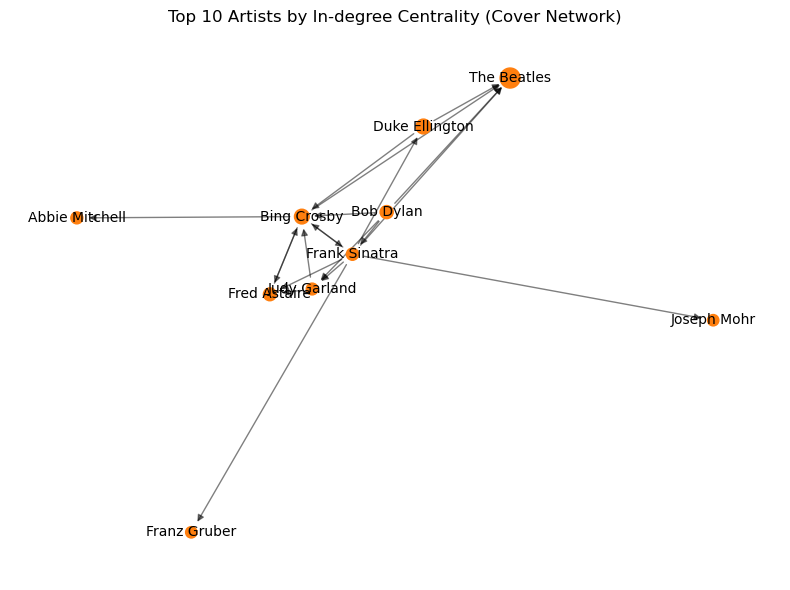

In [ ]:
# Visualize only the top 10 in-degree centrality nodes and their edges in the cover network

# Get top 10 artist IDs by in-degree centrality
top_nodes = in_deg_cov_df['artist_id'].tolist()

# Create a subgraph with only the top 10 nodes and edges between them
G_top10 = G_covered.subgraph(top_nodes).copy()

# Node colors: all orange
node_colors = ["#ff7f0e"] * len(G_top10.nodes())

# Node sizes: scale by in-degree centrality (optional, for visual effect)
sizes = [in_deg_cov_scores[n] * 3000 for n in G_top10.nodes()]

# Draw the network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_top10, seed=42, k=0.5)

nx.draw_networkx_edges(G_top10, pos, alpha=0.5)
nx.draw_networkx_nodes(G_top10, pos, node_color=node_colors, node_size=sizes)
nx.draw_networkx_labels(
    G_top10, pos,
    labels={n: G_covered.nodes[n]['name'] for n in G_top10.nodes()},
    font_size=10,
    font_color='black'
)

plt.title("Top 10 Artists by In-degree Centrality (Cover Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

In [70]:
# PageRank (weighted)
pagerank_cov_scores = nx.pagerank(G_covered, alpha=0.85, weight='weight')
pagerank_cov_df = top_metric_df(pagerank_cov_scores, G_covered, 'pagerank_score')
pagerank_cov_df

,artist_id,artist_name,pagerank_score
0,41,The Beatles,0.012941
1,158,Bob Dylan,0.005808
2,243,Bing Crosby,0.003622
3,616,Depeche Mode,0.003433
4,327,Chuck Berry,0.003406
5,4305,Duke Ellington,0.003387
6,206,The Rolling Stones,0.003340
7,26565,Prince's Band,0.003082
8,90,The Velvet Underground,0.002862
9,1886,Hank Williams,0.002777


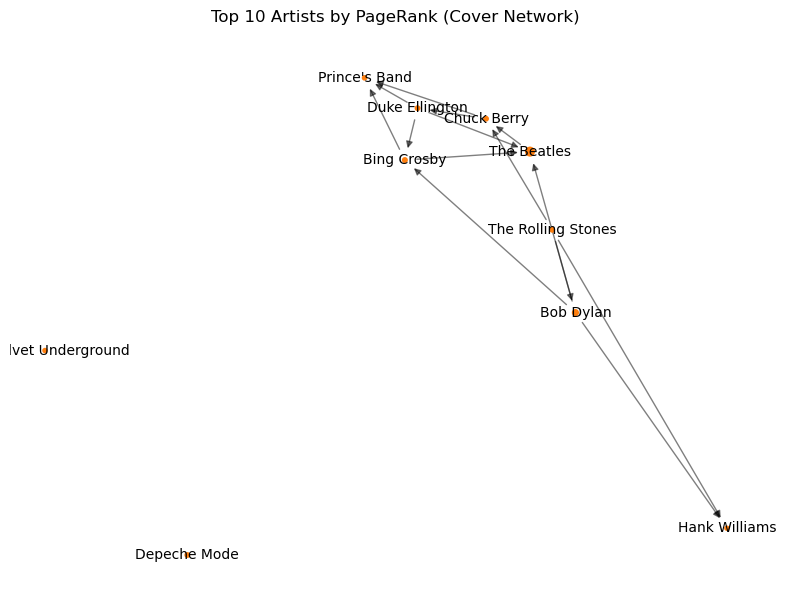

In [ ]:
# Visualize only the top 10 PageRank (weighted) nodes and their edges in the cover network

# Get top 10 artist IDs by PageRank
top_nodes = pagerank_cov_df['artist_id'].tolist()

# Create a subgraph with only the top 10 nodes and edges between them
G_top10 = G_covered.subgraph(top_nodes).copy()

# Node colors: all orange
node_colors = ["#ff7f0e"] * len(G_top10.nodes())

# Node sizes: scale by PageRank score (for visual effect)
sizes = [pagerank_cov_scores[n] * 3000 for n in G_top10.nodes()]

# Draw the network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_top10, seed=42, k=0.5)

nx.draw_networkx_edges(G_top10, pos, alpha=0.5)
nx.draw_networkx_nodes(G_top10, pos, node_color=node_colors, node_size=sizes)
nx.draw_networkx_labels(
    G_top10, pos,
    labels={n: G_covered.nodes[n]['name'] for n in G_top10.nodes()},
    font_size=10,
    font_color='black'
)

plt.title("Top 10 Artists by PageRank (Cover Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

In [71]:
# Betweenness centrality
betweenness_cov_scores = nx.betweenness_centrality(G_covered, k=100)
betweenness_cov_df = top_metric_df(betweenness_cov_scores, G_covered, 'betweenness_centrality')
betweenness_cov_df

,artist_id,artist_name,betweenness_centrality
0,41,The Beatles,0.012931
1,103,Elvis Presley,0.007067
2,158,Bob Dylan,0.005989
3,754,Ray Charles,0.004874
4,243,Bing Crosby,0.004378
5,1085,Percy Faith,0.004325
6,297,U2,0.004299
7,194,David Bowie,0.003922
8,319,Frank Sinatra,0.003870
9,206,The Rolling Stones,0.003845


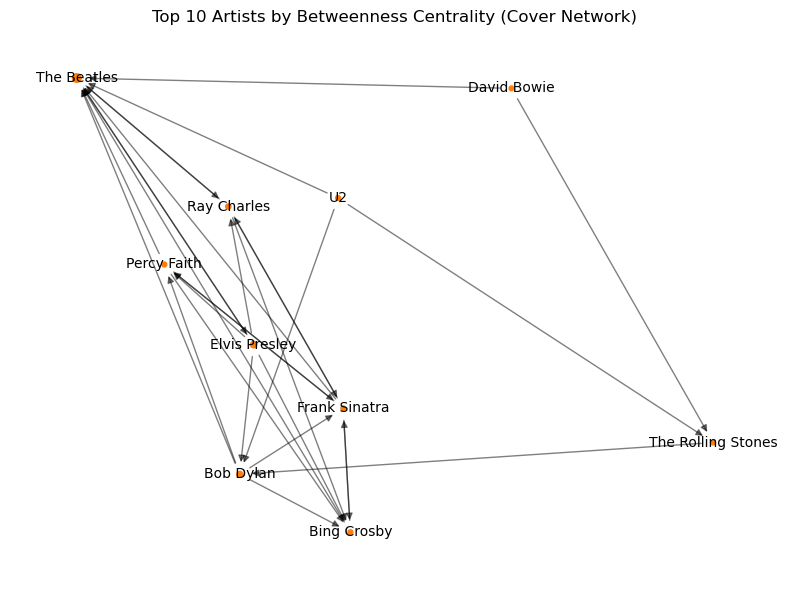

In [ ]:
# Visualize only the top 10 Betweenness Centrality nodes and their edges in the cover network


# Get top 10 artist IDs by betweenness centrality
top_nodes = betweenness_cov_df['artist_id'].tolist()

# Create a subgraph with only the top 10 nodes and edges between them
G_top10 = G_covered.subgraph(top_nodes).copy()

# Node colors: all orange
node_colors = ["#ff7f0e"] * len(G_top10.nodes())

# Node sizes: scale by betweenness centrality (for visual effect)
sizes = [betweenness_cov_scores[n] * 3000 for n in G_top10.nodes()]

# Draw the network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_top10, seed=42, k=0.5)

nx.draw_networkx_edges(G_top10, pos, alpha=0.5)
nx.draw_networkx_nodes(G_top10, pos, node_color=node_colors, node_size=sizes)
nx.draw_networkx_labels(
    G_top10, pos,
    labels={n: G_covered.nodes[n]['name'] for n in G_top10.nodes()},
    font_size=10,
    font_color='black'
)

plt.title("Top 10 Artists by Betweenness Centrality (Cover Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

##### Layout algorithm: The spring_layout tries to minimize edge crossings and node overlap, but with only a few edges among the top 10, nodes with fewer direct connections will be pushed to the edge.
##### High betweenness in the full network does not guarantee a central position in a subgraph of only the top 10 nodes. The visualization reflects direct connections among those top 10, not their role in the entire network.

### Centrality metrics on wiki network

In [72]:
# In-degree centrality
in_deg_ment_scores = nx.in_degree_centrality(G_mentions)
in_deg_ment_df = top_metric_df(in_deg_ment_scores, G_mentions, 'in_degree_centrality')
in_deg_ment_df

,artist_id,artist_name,in_degree_centrality
0,30607,Adele,0.138533
1,8358,Beyoncé,0.132835
2,297,U2,0.127493
3,224,Eminem,0.112536
4,84,Madonna,0.111111
5,211,Metallica,0.090812
6,223,Aerosmith,0.086182
7,10590,Coldplay,0.086182
8,19179,Rihanna,0.085470
9,1060,Bono,0.080128


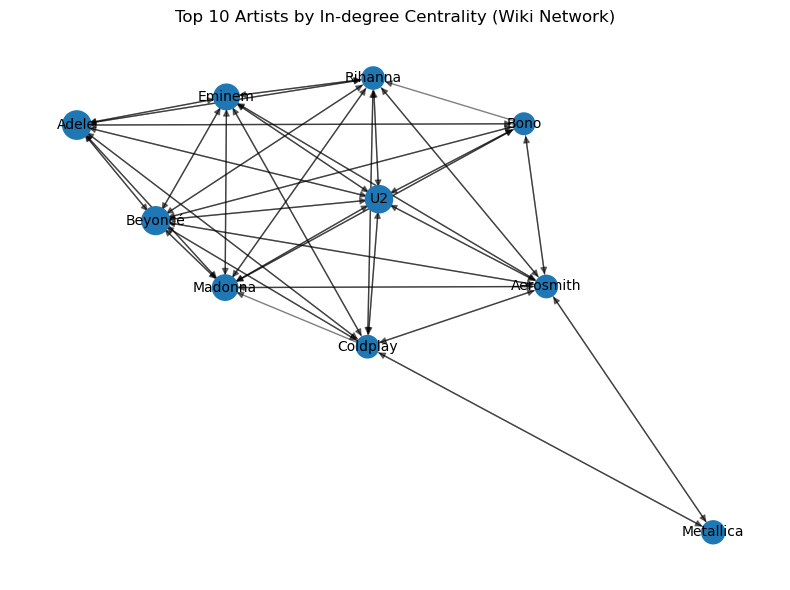

In [ ]:
# Visualize only the top 10 in-degree centrality nodes and their edges in the wiki network

# Get top 10 artist IDs by in-degree centrality
top_nodes = in_deg_ment_df['artist_id'].tolist()

# Create a subgraph with only the top 10 nodes and edges between them
G_top10 = G_mentions.subgraph(top_nodes).copy()

# Node colors: all blue
node_colors = ["#1f77b4"] * len(G_top10.nodes())

# Node sizes: scale by in-degree centrality (for visual effect)
sizes = [in_deg_ment_scores[n] * 3000 for n in G_top10.nodes()]

# Draw the network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_top10, seed=42, k=0.5)

nx.draw_networkx_edges(G_top10, pos, alpha=0.5)
nx.draw_networkx_nodes(G_top10, pos, node_color=node_colors, node_size=sizes)
nx.draw_networkx_labels(
    G_top10, pos,
    labels={n: G_mentions.nodes[n]['name'] for n in G_top10.nodes()},
    font_size=10,
    font_color='black'
)

plt.title("Top 10 Artists by In-degree Centrality (Wiki Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

In [73]:
# PageRank
pagerank_ment_scores = nx.pagerank(G_mentions, alpha=0.85)  # no weights
pagerank_ment_df = top_metric_df(pagerank_ment_scores, G_mentions, 'pagerank_score')
pagerank_ment_df 

,artist_id,artist_name,pagerank_score
0,297,U2,0.027021
1,84,Madonna,0.026064
2,224,Eminem,0.025635
3,8358,Beyoncé,0.025471
4,10590,Coldplay,0.024237
5,223,Aerosmith,0.023370
6,211,Metallica,0.023003
7,19179,Rihanna,0.021258
8,30607,Adele,0.021227
9,248,Jay-Z,0.020720


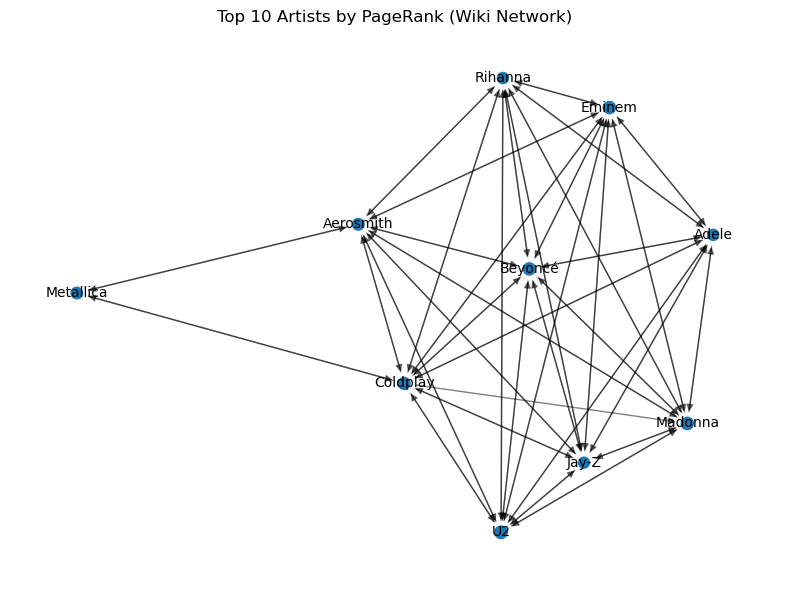

In [ ]:
# Visualize only the top 10 PageRank nodes and their edges in the wiki network

# Get top 10 artist IDs by PageRank
top_nodes = pagerank_ment_df['artist_id'].tolist()

# Create a subgraph with only the top 10 nodes and edges between them
G_top10 = G_mentions.subgraph(top_nodes).copy()

# Node colors: all blue
node_colors = ["#1f77b4"] * len(G_top10.nodes())

# Node sizes: scale by PageRank score (for visual effect)
sizes = [pagerank_ment_scores[n] * 3000 for n in G_top10.nodes()]

# Draw the network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_top10, seed=42, k=0.5)

nx.draw_networkx_edges(G_top10, pos, alpha=0.5)
nx.draw_networkx_nodes(G_top10, pos, node_color=node_colors, node_size=sizes)
nx.draw_networkx_labels(
    G_top10, pos,
    labels={n: G_mentions.nodes[n]['name'] for n in G_top10.nodes()},
    font_size=10,
    font_color='black'
)

plt.title("Top 10 Artists by PageRank (Wiki Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

In [74]:
# Betweenness centrality
betweenness_ment_scores = nx.betweenness_centrality(G_mentions, k=100)
betweenness_ment_df = top_metric_df(betweenness_ment_scores, G_mentions, 'betweenness_centrality')
betweenness_ment_df

,artist_id,artist_name,betweenness_centrality
0,297,U2,0.008633
1,211,Metallica,0.007623
2,10590,Coldplay,0.006813
3,14508,Korn,0.006411
4,84,Madonna,0.006337
5,119,ABBA,0.006037
6,223,Aerosmith,0.005748
7,8358,Beyoncé,0.004466
8,224,Eminem,0.004084
9,13053,Björk,0.004047


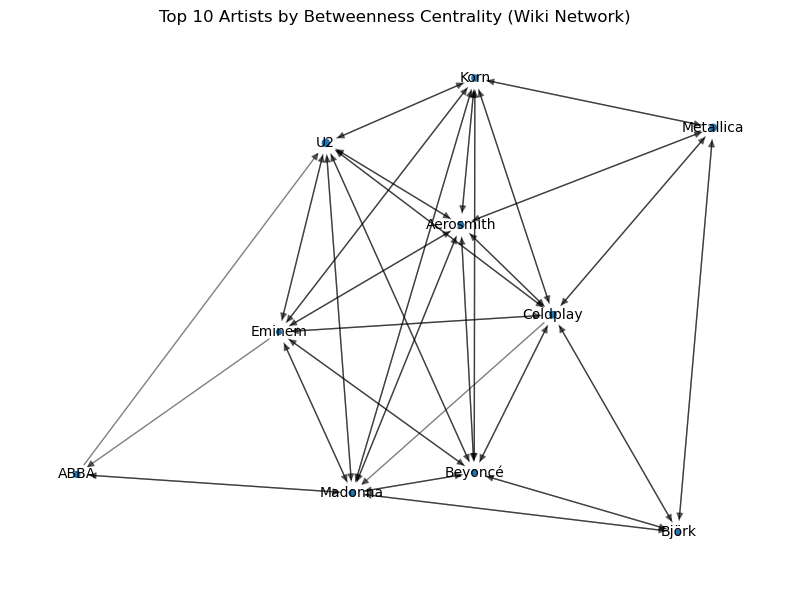

In [ ]:
# Visualize only the top 10 Betweenness Centrality nodes and their edges in the wiki network
# Get top 10 artist IDs by betweenness centrality
top_nodes = betweenness_ment_df['artist_id'].tolist()

# Create a subgraph with only the top 10 nodes and edges between them
G_top10 = G_mentions.subgraph(top_nodes).copy()

# Node colors: all blue
node_colors = ["#1f77b4"] * len(G_top10.nodes())

# Node sizes: scale by betweenness centrality (for visual effect)
sizes = [betweenness_ment_scores[n] * 3000 for n in G_top10.nodes()]

# Draw the network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_top10, seed=42, k=0.5)

nx.draw_networkx_edges(G_top10, pos, alpha=0.5)
nx.draw_networkx_nodes(G_top10, pos, node_color=node_colors, node_size=sizes)
nx.draw_networkx_labels(
    G_top10, pos,
    labels={n: G_mentions.nodes[n]['name'] for n in G_top10.nodes()},
    font_size=10,
    font_color='black'
)

plt.title("Top 10 Artists by Betweenness Centrality (Wiki Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

### Genre-specific centrality metrics - in progress
In-degree should be fine, we just need to decide how we normalize. 
but pagerank and betweenness is just some chatgpt code and i am not sure if it makes sense

In [75]:
def genres_similar(genres1, genres2, threshold=0.5):
    """Return True if overlap ratio >= threshold, else False."""
    set1, set2 = set(genres1), set(genres2)
    if not set1 or not set2:
        return False
    overlap = len(set1.intersection(set2))
    overlap_ratio = overlap / max(len(set1), len(set2))
    return overlap_ratio >= threshold

cross_genre_in_degree = {}

for node in G_covered.nodes():
    node_genres = G_covered.nodes[node].get('genres')

    # Check if pred_genres is None or empty (list/Series)
    if not node_genres:
        continue

    # sum in-degree edges from nodes with sufficiently different genres
    cross_in_degree = 0
    for pred in G_covered.predecessors(node):
        pred_genres = G_covered.nodes[pred].get('genres')

        if not pred_genres:
            continue

        if not genres_similar(node_genres, pred_genres):
            # weighted in-degree edge if weight attribute exists, else count 1
            weight = G_covered[pred][node].get('weight', 1)
            cross_in_degree += weight

    cross_genre_in_degree[node] = cross_in_degree

# Optional normalization by total in-degree (weighted)
# Set minimum threshold for total in-degree to consider normalization valid
min_total_in_degree = 1000

normalized_cross_in_degree = {}
for node, cross_val in cross_genre_in_degree.items():
    total_in_degree = sum(G_covered[pred][node].get('weight', 1) for pred in G_covered.predecessors(node))
    if total_in_degree >= min_total_in_degree:
        normalized_cross_in_degree[node] = cross_val / total_in_degree
    else:
        normalized_cross_in_degree[node] = 0  # or np.nan if you want to mark it as missing

# Display top 10 cross-genre in-degree (absolute)
top_cross_in_degree_df = top_metric_df(cross_genre_in_degree, G_covered, 'cross_genre_in_degree')
display(top_cross_in_degree_df)

# Display top 10 normalized cross-genre in-degree
top_norm_cross_in_degree_df = top_metric_df(normalized_cross_in_degree, G_covered, 'normalized_cross_genre_in_degree')
display(top_norm_cross_in_degree_df)

,artist_id,artist_name,cross_genre_in_degree
0,41,The Beatles,676
1,158,Bob Dylan,591
2,243,Bing Crosby,350
3,1886,Hank Williams,328
4,103,Elvis Presley,262
5,319,Frank Sinatra,255
6,1496,Billie Holiday,151
7,1424,Judy Garland,130
8,1000,Little Richard,124
9,754,Ray Charles,119


,artist_id,artist_name,normalized_cross_genre_in_degree
0,1886,Hank Williams,0.183857
1,158,Bob Dylan,0.170317
2,319,Frank Sinatra,0.100275
3,243,Bing Crosby,0.097276
4,233,Henry Mancini,0.093857
5,1496,Billie Holiday,0.092355
6,103,Elvis Presley,0.085370
7,320,Nat King Cole,0.076722
8,1424,Judy Garland,0.073822
9,41,The Beatles,0.070623


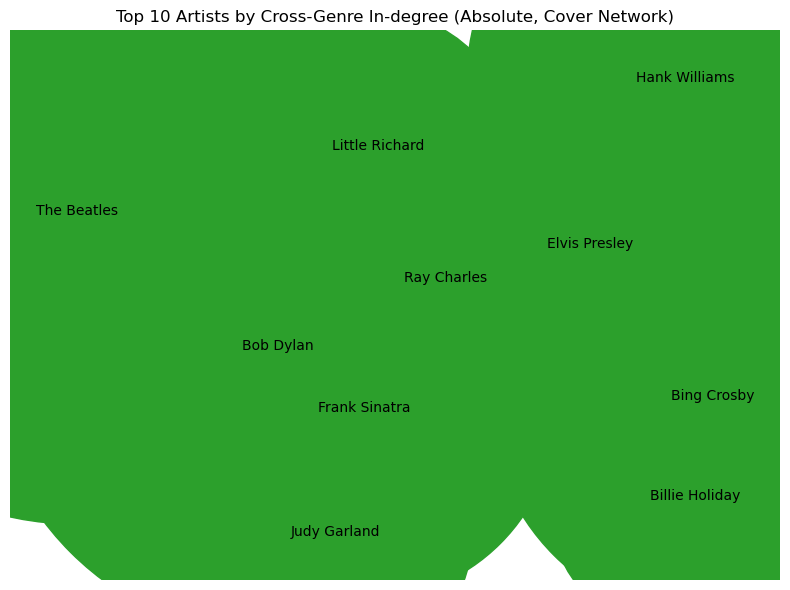

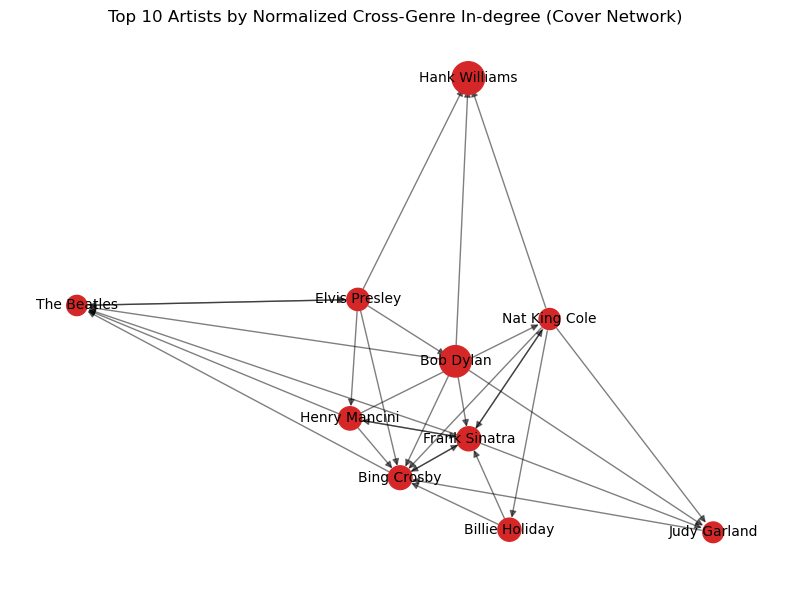

In [85]:
# Visualize top 10 cross-genre in-degree (absolute) in the cover network

# --- Absolute cross-genre in-degree ---
top_nodes_abs = top_cross_in_degree_df['artist_id'].tolist()
G_top10_abs = G_covered.subgraph(top_nodes_abs).copy()
node_colors_abs = ["#2ca02c"] * len(G_top10_abs.nodes())
sizes_abs = [cross_genre_in_degree[n] * 300 for n in G_top10_abs.nodes()]  # scale for visibility

plt.figure(figsize=(8, 6))
pos_abs = nx.spring_layout(G_top10_abs, seed=42, k=0.5)
nx.draw_networkx_edges(G_top10_abs, pos_abs, alpha=0.5)
nx.draw_networkx_nodes(G_top10_abs, pos_abs, node_color=node_colors_abs, node_size=sizes_abs)
nx.draw_networkx_labels(
    G_top10_abs, pos_abs,
    labels={n: G_covered.nodes[n]['name'] for n in G_top10_abs.nodes()},
    font_size=10,
    font_color='black'
)
plt.title("Top 10 Artists by Cross-Genre In-degree (Absolute, Cover Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

# --- Normalized cross-genre in-degree ---
top_nodes_norm = top_norm_cross_in_degree_df['artist_id'].tolist()
G_top10_norm = G_covered.subgraph(top_nodes_norm).copy()
node_colors_norm = ["#d62728"] * len(G_top10_norm.nodes())
sizes_norm = [normalized_cross_in_degree[n] * 3000 for n in G_top10_norm.nodes()]  # scale for visibility

plt.figure(figsize=(8, 6))
pos_norm = nx.spring_layout(G_top10_norm, seed=42, k=0.5)
nx.draw_networkx_edges(G_top10_norm, pos_norm, alpha=0.5)
nx.draw_networkx_nodes(G_top10_norm, pos_norm, node_color=node_colors_norm, node_size=sizes_norm)
nx.draw_networkx_labels(
    G_top10_norm, pos_norm,
    labels={n: G_covered.nodes[n]['name'] for n in G_top10_norm.nodes()},
    font_size=10,
    font_color='black'
)
plt.title("Top 10 Artists by Normalized Cross-Genre In-degree (Cover Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

### The absolue network looks so ugly because our nodes are scaled (node size is proportional to the cross-genre covers) what we are basically seeing now are nodes (Green nodes, "#2ca02c" is green )

In [ ]:
# Compute full PageRank on G_covered with weights
pagerank_scores = nx.pagerank(G_covered, alpha=0.85, weight='weight')

cross_genre_pagerank = {}

for node in G_covered.nodes():
    node_genres = G_covered.nodes[node].get('genres')

    if not node_genres:
        continue

    cross_pr = 0
    for pred in G_covered.predecessors(node):
        pred_genres = G_covered.nodes[pred].get('genres')
        if not pred_genres:
            continue

        if not genres_similar(node_genres, pred_genres):
            # Add the fraction of pagerank flow from that predecessor to this node,
            # weighted by edge weight and normalized by predecessor's out-degree weights
            edge_weight = G_covered[pred][node].get('weight', 1)
            pred_out_weight_sum = sum(G_covered[pred][succ].get('weight', 1) for succ in G_covered.successors(pred))
            if pred_out_weight_sum > 0:
                cross_pr += (pagerank_scores[pred] * edge_weight) / pred_out_weight_sum

    cross_genre_pagerank[node] = cross_pr

# Optional normalization by total pagerank score of node
min_total_pr = 0.001  # threshold for minimum pagerank to consider normalization meaningful

normalized_cross_genre_pagerank = {}
for node, cross_val in cross_genre_pagerank.items():
    total_pr = pagerank_scores.get(node, 0)
    if total_pr >= min_total_pr:
        normalized_cross_genre_pagerank[node] = cross_val / total_pr
    else:
        normalized_cross_genre_pagerank[node] = 0  # or np.nan if preferred

# Display top 10 cross-genre pagerank (absolute)
top_cross_pr_df = top_metric_df(cross_genre_pagerank, G_covered, 'cross_genre_pagerank')
display(top_cross_pr_df)

# Display top 10 normalized cross-genre pagerank
top_norm_cross_pr_df = top_metric_df(normalized_cross_genre_pagerank, G_covered, 'normalized_cross_genre_pagerank')
display(top_norm_cross_pr_df)


,artist_id,artist_name,cross_genre_pagerank
0,158,Bob Dylan,0.001998
1,41,The Beatles,0.001849
2,1000,Little Richard,0.001255
3,1886,Hank Williams,0.001123
4,754,Ray Charles,0.001054
5,243,Bing Crosby,0.000910
6,103,Elvis Presley,0.000872
7,319,Frank Sinatra,0.000851
8,202,Muddy Waters,0.000644
9,14535,Bobby Parker,0.000627


,artist_id,artist_name,normalized_cross_genre_pagerank
0,1000,Little Richard,0.689219
1,754,Ray Charles,0.516909
2,7010,Jimmy Reed,0.467209
3,202,Muddy Waters,0.436765
4,11034,Bo Diddley,0.405085
5,1886,Hank Williams,0.404310
6,319,Frank Sinatra,0.397763
7,8191,Gene Autry,0.393169
8,103,Elvis Presley,0.363818
9,158,Bob Dylan,0.343983


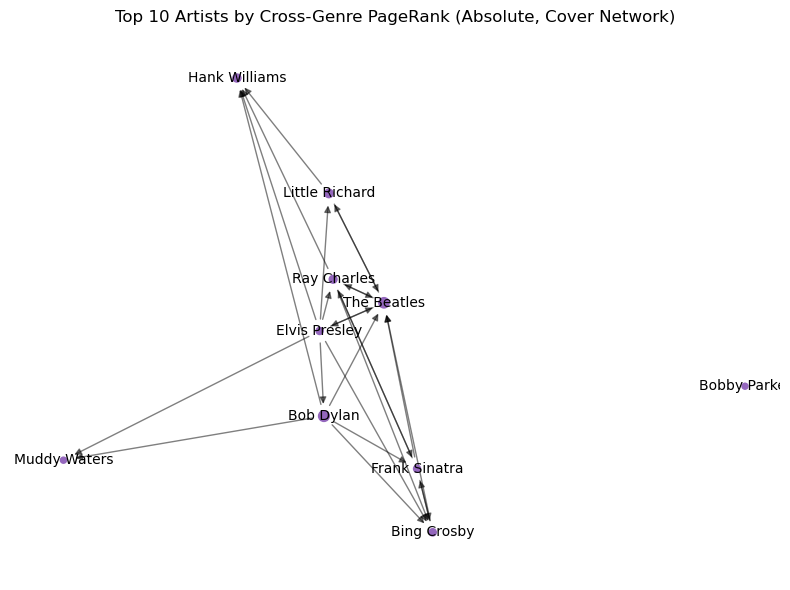

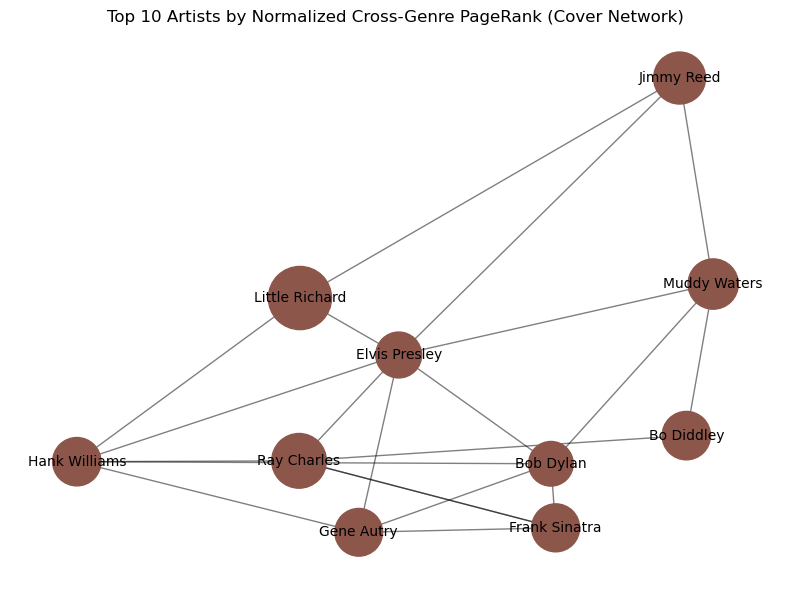

In [86]:
# Visualize top 10 cross-genre PageRank (absolute and normalized) in the cover network

# --- Absolute cross-genre PageRank ---
top_nodes_pr_abs = top_cross_pr_df['artist_id'].tolist()
G_top10_pr_abs = G_covered.subgraph(top_nodes_pr_abs).copy()
node_colors_pr_abs = ["#9467bd"] * len(G_top10_pr_abs.nodes())  # purple
sizes_pr_abs = [cross_genre_pagerank[n] * 30000 for n in G_top10_pr_abs.nodes()]  # scale for visibility

plt.figure(figsize=(8, 6))
pos_pr_abs = nx.spring_layout(G_top10_pr_abs, seed=42, k=0.5)
nx.draw_networkx_edges(G_top10_pr_abs, pos_pr_abs, alpha=0.5)
nx.draw_networkx_nodes(G_top10_pr_abs, pos_pr_abs, node_color=node_colors_pr_abs, node_size=sizes_pr_abs)
nx.draw_networkx_labels(
    G_top10_pr_abs, pos_pr_abs,
    labels={n: G_covered.nodes[n]['name'] for n in G_top10_pr_abs.nodes()},
    font_size=10,
    font_color='black'
)
plt.title("Top 10 Artists by Cross-Genre PageRank (Absolute, Cover Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

# --- Normalized cross-genre PageRank ---
top_nodes_pr_norm = top_norm_cross_pr_df['artist_id'].tolist()
G_top10_pr_norm = G_covered.subgraph(top_nodes_pr_norm).copy()
node_colors_pr_norm = ["#8c564b"] * len(G_top10_pr_norm.nodes())  # brown
sizes_pr_norm = [normalized_cross_genre_pagerank[n] * 3000 for n in G_top10_pr_norm.nodes()]  # scale for visibility

plt.figure(figsize=(8, 6))
pos_pr_norm = nx.spring_layout(G_top10_pr_norm, seed=42, k=0.5)
nx.draw_networkx_edges(G_top10_pr_norm, pos_pr_norm, alpha=0.5)
nx.draw_networkx_nodes(G_top10_pr_norm, pos_pr_norm, node_color=node_colors_pr_norm, node_size=sizes_pr_norm)
nx.draw_networkx_labels(
    G_top10_pr_norm, pos_pr_norm,
    labels={n: G_covered.nodes[n]['name'] for n in G_top10_pr_norm.nodes()},
    font_size=10,
    font_color='black'
)
plt.title("Top 10 Artists by Normalized Cross-Genre PageRank (Cover Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

In [77]:
# Compute betweenness centrality on G_covered (approximate with k=100)
betweenness_scores = nx.betweenness_centrality(G_covered, k=100)

cross_genre_betweenness = {}

for node in G_covered.nodes():
    node_genres = G_covered.nodes[node].get('genres')

    if not node_genres:
        continue

    cross_btw = 0
    for pred in G_covered.predecessors(node):
        pred_genres = G_covered.nodes[pred].get('genres')
        if not pred_genres:
            continue

        if not genres_similar(node_genres, pred_genres):
            # Sum betweenness from predecessor nodes connected by edges crossing genres
            cross_btw += betweenness_scores.get(pred, 0)

    cross_genre_betweenness[node] = cross_btw

# Optional normalization by total betweenness score of node
min_total_btw = 0.0001  # threshold for minimum betweenness to consider normalization meaningful

normalized_cross_genre_betweenness = {}
for node, cross_val in cross_genre_betweenness.items():
    total_btw = betweenness_scores.get(node, 0)
    if total_btw >= min_total_btw:
        normalized_cross_genre_betweenness[node] = cross_val / total_btw
    else:
        normalized_cross_genre_betweenness[node] = 0  # or np.nan if preferred

# Display top 10 cross-genre betweenness (absolute)
top_cross_btw_df = top_metric_df(cross_genre_betweenness, G_covered, 'cross_genre_betweenness')
display(top_cross_btw_df)

# Display top 10 normalized cross-genre betweenness
top_norm_cross_btw_df = top_metric_df(normalized_cross_genre_betweenness, G_covered, 'normalized_cross_genre_betweenness')
display(top_norm_cross_btw_df)

,artist_id,artist_name,cross_genre_betweenness
0,41,The Beatles,0.069817
1,1415,Don Gibson,0.054544
2,243,Bing Crosby,0.051884
3,6872,Jimmy Dorsey,0.046582
4,21291,Simon and Garfunkel,0.043404
5,158,Bob Dylan,0.043207
6,1886,Hank Williams,0.042950
7,754,Ray Charles,0.041622
8,319,Frank Sinatra,0.036610
9,8029,Little Willie John,0.034907


,artist_id,artist_name,normalized_cross_genre_betweenness
0,7428,Ray Noble,287.850240
1,734,Roger Miller,219.141768
2,4217,Glenn Miller,217.187435
3,8029,Little Willie John,207.378454
4,13235,John Hartford,181.492522
5,8191,Gene Autry,177.945720
6,509,Creedence Clearwater Revival,173.534038
7,1886,Hank Williams,145.288913
8,26159,Eddie Fontaine,131.414631
9,2835,Julie Andrews,128.898266


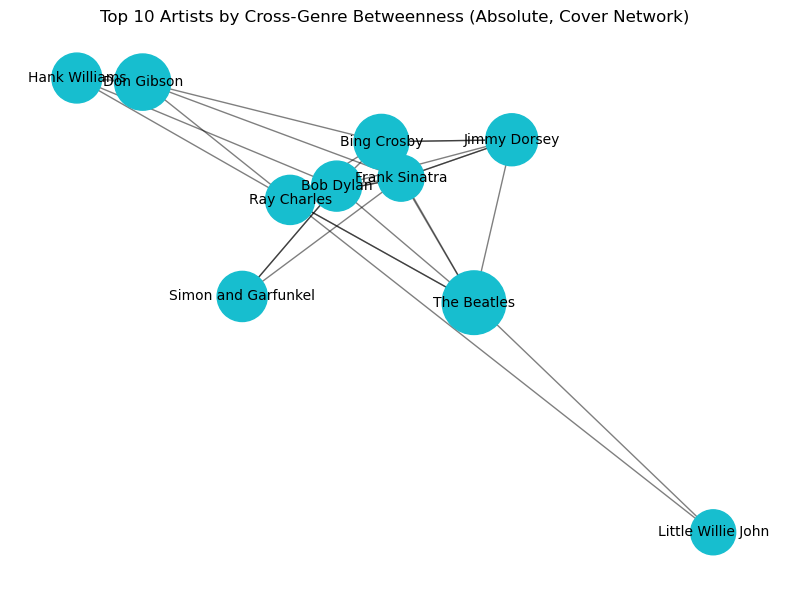

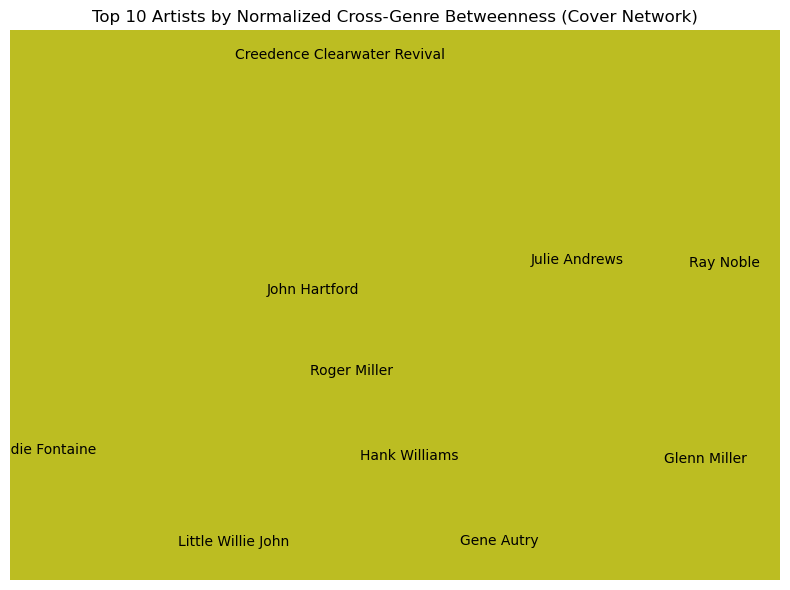

In [87]:
# Visualize top 10 cross-genre betweenness (absolute and normalized) in the cover network

# --- Absolute cross-genre betweenness ---
top_nodes_btw_abs = top_cross_btw_df['artist_id'].tolist()
G_top10_btw_abs = G_covered.subgraph(top_nodes_btw_abs).copy()
node_colors_btw_abs = ["#17becf"] * len(G_top10_btw_abs.nodes())  # cyan
sizes_btw_abs = [cross_genre_betweenness[n] * 30000 for n in G_top10_btw_abs.nodes()]  # scale for visibility

plt.figure(figsize=(8, 6))
pos_btw_abs = nx.spring_layout(G_top10_btw_abs, seed=42, k=0.5)
nx.draw_networkx_edges(G_top10_btw_abs, pos_btw_abs, alpha=0.5)
nx.draw_networkx_nodes(G_top10_btw_abs, pos_btw_abs, node_color=node_colors_btw_abs, node_size=sizes_btw_abs)
nx.draw_networkx_labels(
    G_top10_btw_abs, pos_btw_abs,
    labels={n: G_covered.nodes[n]['name'] for n in G_top10_btw_abs.nodes()},
    font_size=10,
    font_color='black'
)
plt.title("Top 10 Artists by Cross-Genre Betweenness (Absolute, Cover Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

# --- Normalized cross-genre betweenness ---
top_nodes_btw_norm = top_norm_cross_btw_df['artist_id'].tolist()
G_top10_btw_norm = G_covered.subgraph(top_nodes_btw_norm).copy()
node_colors_btw_norm = ["#bcbd22"] * len(G_top10_btw_norm.nodes())  # olive
sizes_btw_norm = [normalized_cross_genre_betweenness[n] * 3000 for n in G_top10_btw_norm.nodes()]  # scale for visibility

plt.figure(figsize=(8, 6))
pos_btw_norm = nx.spring_layout(G_top10_btw_norm, seed=42, k=0.5)
nx.draw_networkx_edges(G_top10_btw_norm, pos_btw_norm, alpha=0.5)
nx.draw_networkx_nodes(G_top10_btw_norm, pos_btw_norm, node_color=node_colors_btw_norm, node_size=sizes_btw_norm)
nx.draw_networkx_labels(
    G_top10_btw_norm, pos_btw_norm,
    labels={n: G_covered.nodes[n]['name'] for n in G_top10_btw_norm.nodes()},
    font_size=10,
    font_color='black'
)
plt.title("Top 10 Artists by Normalized Cross-Genre Betweenness (Cover Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

### Same problem as above, the numbers in the table are huge as well in comparison to the other tables where numbers are smaller than 1